In [42]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jp

import jax_model

In [37]:
import importlib; importlib.reload(jax_model)

<module 'jax_model' from '/home/emil/Development/torque-lever-simulation/jax_model.py'>

In [43]:
key = jax.random.key(seed=123)

In [38]:
sim = jax_model.TorqueLeverSimulationJAX(
    lever_mass = 3.5e-3,    #kg
    lever_length = 15e-2,   #meter
    lever_range = (30, 100), #degrees
    motor_baseline_torque = 3e-3,
    motor_extra_torque = 2e-2,
    motor_onset_angle = (75, 80),
    friction_coeff = 0.0e-3,
    dt=1e-3
)

In [39]:
tt = jp.linspace(0, 1, 500)
true_force = -jp.sin(4*tt)**2*tt - 0.1*tt**2
true_theta = sim.run(true_force)

In [46]:
candidates = jax.random.normal(key, (100, 500))


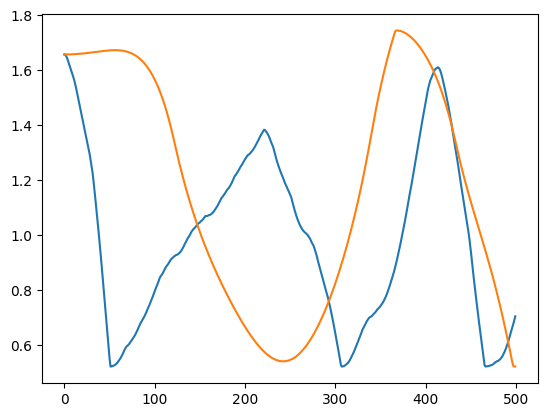

In [57]:
plt.plot(jp.arange(500), cand_theta[2], true_theta)

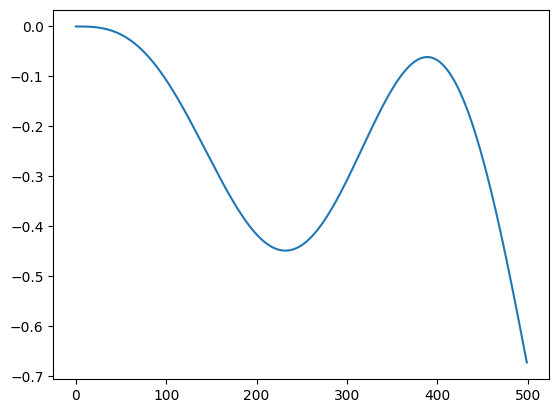

In [59]:
plt.plot(true_force)

In [325]:
xx, yy = jp.meshgrid(jp.arange(500), jp.arange(500))
S = (jp.exp(-((xx-yy)/25.0)**2) + 1e-5*jp.eye(500))

In [397]:
mean_force = -0.5*jp.ones(500)
mean_theta = sim.run(mean_force)
key = jax.random.key(seed=123)

In [406]:
key, = jax.random.split(key, 1)
candidates = mean_force + 0.5*jax.random.multivariate_normal(key, jp.zeros(500), S, (1000,))
#candidates = jp.clip(candidates, -2, 0)
cand_theta = jax.vmap(sim.run)(candidates)
l2_errs = jax.vmap(jp.linalg.norm)(cand_theta - true_theta)
weights = jax.nn.softmax(-l2_errs/l2_errs.min() * 5)
mean_force = jp.sum(weights[:, jp.newaxis] * candidates, axis=0)
mean_theta = jp.sum(weights[:, jp.newaxis] * cand_theta, axis=0)
pred_theta = sim.run(mean_force)

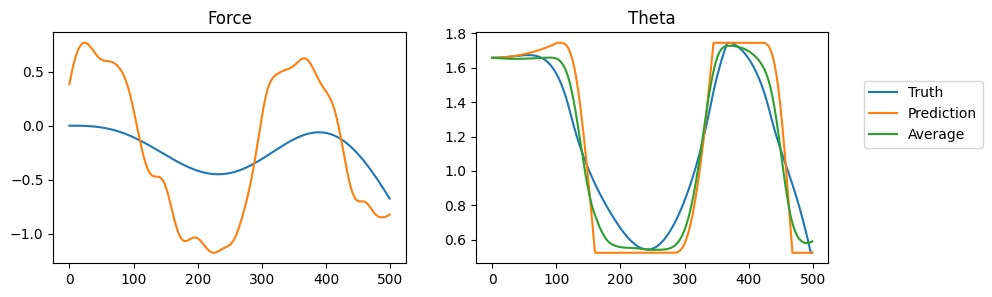

In [407]:
fig, axs = plt.subplots(1,2,figsize=(10, 3))
axs[0].set_title("Force")
axs[0].plot(true_force, label="Truth")
axs[0].plot(mean_force, label="Prediction")
axs[1].set_title("Theta")
axs[1].plot(true_theta, label="Truth")
axs[1].plot(pred_theta, label="Prediction")
axs[1].plot(mean_theta, label="Average")
axs[1].legend(loc=(1.1, 0.5))
plt.show()

In [368]:
l2_errs.min()

Array(5.857336, dtype=float32)

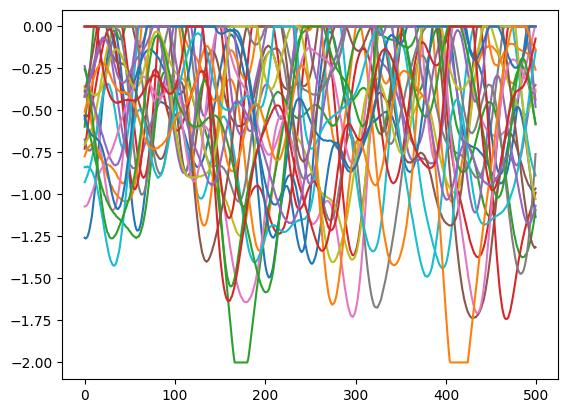

In [369]:
for i in range(25):
    plt.plot(candidates[i])
plt.show()

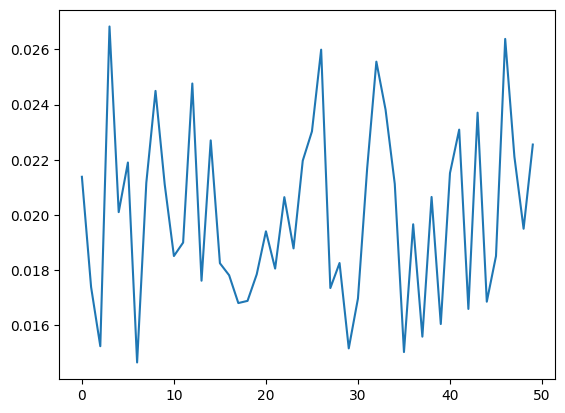

In [275]:
plt.plot(weights)

In [669]:
candidates = 0.5 * jax.random.multivariate_normal(key, jp.zeros(500), S, (1000,))
candidates = jp.clip(candidates, -2.0, 0.0)

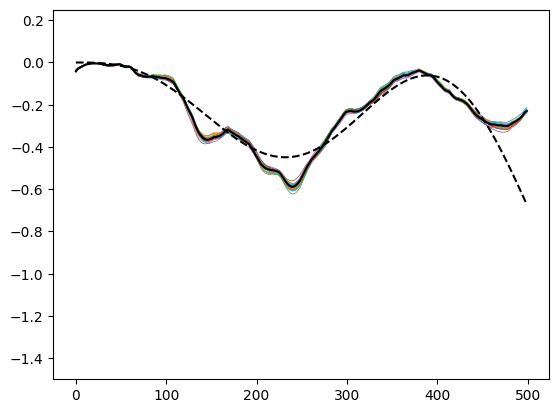

In [678]:
cand_theta = jax.vmap(sim.run)(candidates)
l2_errs = jax.vmap(jp.linalg.norm)(cand_theta - true_theta)
survivors_inds = jp.argsort(l2_errs)[:200]
survivors = candidates[survivors_inds]
key, key_a, key_b = jax.random.split(key, 3)
candidates = 0.5 * (jax.random.choice(key_a, survivors, (1000,)) + jax.random.choice(key_b, survivors, (1000,)))
#candidates += 0.1*jp.std(candidates, axis=0)*jax.random.normal(key, (500,))
candidates = jp.clip(candidates, -2.0, 0.0)
for i in range(25):
    plt.plot(candidates[i], lw=0.5)
plt.plot(jp.mean(candidates, axis=0), 'k')
plt.plot(true_force, 'k--')
plt.ylim(-1.5, 0.25)
plt.show()

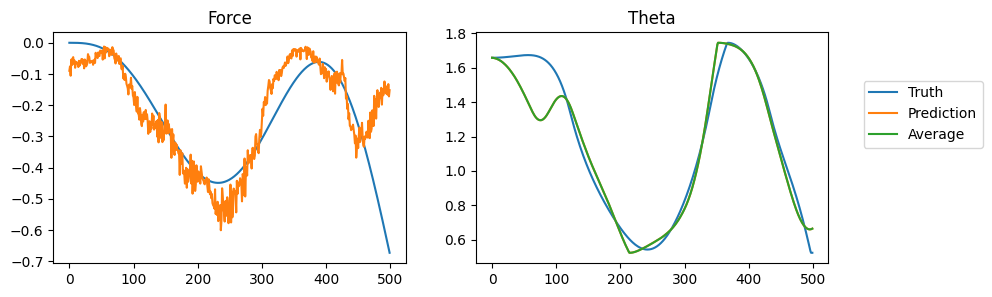

In [654]:
mean_force = jp.mean(candidates, axis=0)
pred_theta = sim.run(mean_force)
mean_theta = jp.mean(jax.vmap(sim.run)(candidates), axis=0)
fig, axs = plt.subplots(1,2,figsize=(10, 3))
axs[0].set_title("Force")
axs[0].plot(true_force, label="Truth")
axs[0].plot(mean_force, label="Prediction")
axs[1].set_title("Theta")
axs[1].plot(true_theta, label="Truth")
axs[1].plot(pred_theta, label="Prediction")
axs[1].plot(mean_theta, label="Average")
axs[1].legend(loc=(1.1, 0.5))
plt.show()